In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
import koreanize_matplotlib

In [2]:
# TF-IDF
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

# 1. TF-IDF 분석
    * 가중치 높은 태그 확인을 통해 지역별 관광지 특성 구체화 

* 데이터 로드

In [3]:
da = pd.read_csv('10_visit_jeju_c1_tag_final_cleaned_for_da.csv', encoding='utf-8')
da = pd.DataFrame(da)
da.head(3)

,contentsid,title,roadaddress,introduction,latitude,longitude,phoneno,region1cd_value,region1cd_label,region2cd_value,region2cd_label,repPhoto_descseo,repPhoto_photoid_photoid,repPhoto_photoid_imgpath,repPhoto_photoid_thumbnailpath,by_region_label,merged_tag_cleaned_for_da
0,CNTS_000000000019003,제주국제예술센터,제주특별자치도 서귀포시 대정읍 서삼중로 117,제주의 문화와 예술이 담긴 곳,33.271830,126.199440,010-4696-8799,region2,서귀포시,22,대정,제주국제예술센터,4131,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_서부,"예술,실내,미술,박물관,흐림,사계절,실내관광지,어트랙션"
1,CNTS_300000000012728,제주펫스쿨,제주특별자치도 서귀포시 대정읍 칠전로 438,“반려견과 보호자가 함께하는 올바른 반려문화를 만들어요.”\r\n 제주펫스쿨에서는 ...,33.286427,126.223154,0507-1365-4504,region2,서귀포시,22,대정,제주펫스쿨,2019022621770,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_서부,"반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험"
2,CNTS_300000000013522,샤카다이브,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1,제주 서귀포시에 위치한 다이빙샵 샤카다이브 입니다,33.325226,126.596193,010-2335-6446,region2,서귀포시,25,남원,샤카다이브,2019022651417,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,서귀포시_동부,"해양스포츠,스쿠버다이빙,체험다이빙,야간다이빙,자격증코스,펀다이빙,영어,실내,실외,체..."


In [4]:
# 558행 이상 태그 수정
da.loc[558,'merged_tag_cleaned_for_da'] = da.loc[558,'merged_tag_cleaned_for_da'].replace('010-4051-6867', "")
da.loc[558,'merged_tag_cleaned_for_da'] = da.loc[558,'merged_tag_cleaned_for_da'].replace('PADIOWD~PADIIDC까지진행가능', "")
da.loc[558,'merged_tag_cleaned_for_da'] = da.loc[558,'merged_tag_cleaned_for_da'].replace(',,', ",")
da.loc[558,'merged_tag_cleaned_for_da']

'스쿠버다이빙,해양레저,체험,액티비티,영어,실내,실외,해양스포츠,레저,수상레저,어트랙션'

In [5]:
# 사용할 칼럼 선택

In [6]:
da = da[['title', 'roadaddress', 'introduction', 'latitude',
       'longitude', 'phoneno', 'region2cd_label', 'by_region_label',
       'merged_tag_cleaned_for_da']]
da.head(3)

,title,roadaddress,introduction,latitude,longitude,phoneno,region2cd_label,by_region_label,merged_tag_cleaned_for_da
0,제주국제예술센터,제주특별자치도 서귀포시 대정읍 서삼중로 117,제주의 문화와 예술이 담긴 곳,33.271830,126.199440,010-4696-8799,대정,서귀포시_서부,"예술,실내,미술,박물관,흐림,사계절,실내관광지,어트랙션"
1,제주펫스쿨,제주특별자치도 서귀포시 대정읍 칠전로 438,“반려견과 보호자가 함께하는 올바른 반려문화를 만들어요.”\r\n 제주펫스쿨에서는 ...,33.286427,126.223154,0507-1365-4504,대정,서귀포시_서부,"반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험"
2,샤카다이브,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1,제주 서귀포시에 위치한 다이빙샵 샤카다이브 입니다,33.325226,126.596193,010-2335-6446,남원,서귀포시_동부,"해양스포츠,스쿠버다이빙,체험다이빙,야간다이빙,자격증코스,펀다이빙,영어,실내,실외,체..."


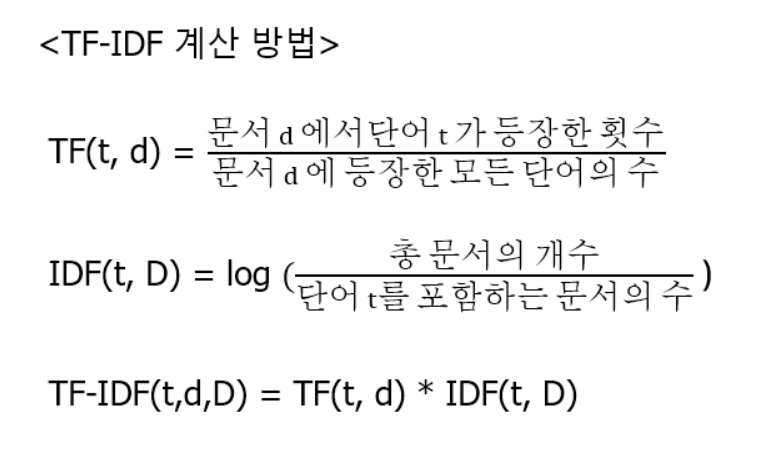

#### [분석 설명]

    * 이전 EDA 단계에서 태그량이 적었던 섬속의 섬들은 분석 대상에서 제외함. 
    * 관광지 태그에서 중복 태그를 이미 없앤 상태라 TF값의 영향이 적음. 
    * 전체 문서(관광지) 중에서 그 단어가 얼마나 드문지를 나타내는 IDF가 TF-IDF 가중치에 실질적인 영향을 줌.               
    * '어트랙션'은 특별한 의미가 없는 태그지만 빈도수가 가장 많음. 또한 태그 수가 적은 문서에서 상대 비중이 커져 결과를 왜곡이 가능해 불용어로 처리

In [7]:
# 섬들은 분석 대상에서 제외
exclude_islands = ["마라도","우도","비양도","가파도","차귀도","추자도"]
da = da.drop(index=da.index[ da["region2cd_label"].isin(exclude_islands) ], axis=0)
print( da["region2cd_label"].isin(exclude_islands).any() ) 

False


In [8]:
corpus = da["merged_tag_cleaned_for_da"]
titles = da["title"]


tfidfvect = TfidfVectorizer(
    tokenizer=lambda s: [t.strip() for t in s.split(",") if t.strip()],    #벡터화   
    token_pattern=None,
    stop_words=["어트랙션"] #어트랙션 불용어 처리

)

dtm = tfidfvect.fit_transform(corpus)
terms = tfidfvect.get_feature_names_out()

In [9]:
# 각 문서(관광지) × 단어(태그)의 TF-IDF 가중치로 구성된 희소 행렬
df_dtm = pd.DataFrame(dtm.toarray(), index=titles,columns=terms)
df_dtm.head(10)

,2022_마을산책_봄,2022고메페스타,2023_관광10선_가을,2023_관광10선_봄,4.3,6월제주여행,6차산업,7월제주,7월제주여행,aida,...,휴식,휴양림,흐림,흑돼지,흑염소,흙,힐링,힐링여행,힐링제주,힐링코스
title,,,,,,,,,,,,,,,,,,,,,
제주국제예술센터,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.348729,0.0,0.0,0.0,0.0,0.0,0.0,0.0
제주펫스쿨,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
샤카다이브,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
그림휴가,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
하이어스 제주,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
뎁스원 프리다이빙센터,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
곽지패총,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
발이오름,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
오림반,0.0,0.0,0.0,0.0,0.540346,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
regions = da["region2cd_label"].astype(str).values


tmp = df_dtm.copy() # 지역별 평균 TF-IDF (행=지역, 열=태그)
tmp["region2cd_label"] = regions
region_mean = tmp.groupby("region2cd_label").mean()

# 지역별 핵심 태그 Top3 출력
for r in region_mean.index:
    top3 = region_mean.loc[r].sort_values(ascending=False).head(3)
    print(f"✔️ {r}: " + ", ".join(top3.index))


✔️ 구좌: 자연경관, 맑음, 커플
✔️ 남원: 자연경관, 커플, 체험
✔️ 대정: 문화유적지, 역사유적, 문화관광
✔️ 서귀포시내: 자연경관, 맑음, 커플
✔️ 성산: 자연경관, 맑음, 커플
✔️ 안덕: 자연경관, 친구, 도보여행
✔️ 애월: 자연경관, 문화유적지, 걷기
✔️ 제주시내: 문화관광, 역사유적, 문화유적지
✔️ 조천: 역사유적, 문화유적지, 문화관광
✔️ 중문: 체험, 실내, 아이
✔️ 표선: 도보여행, 도보, 친구
✔️ 한경: 등산, 걷기, 가을
✔️ 한림: 문화유적지, 역사유적, 문화관광


# 2.TF-IDF 결과 해석

* 관광지 전체에 반복적으로 등장하는 태그에 가중치가 낮게 부여되어 지역별 특성이 상대적으로 선명하게 드러남          
* 특히 기존에 단순히 동행인 중심(커플, 친구, 가족 등)으로만 구분되던 지역들이, TF-IDF 분석을 통해 보다 구체적이고 명확한 테마로 세분화됨.                     
    ex. 조천 : 문화유적, 역사                
        성산 : 자연경관, 커플              
        표선 : 트레킹, 친구               
        애월 : 자연경관, 문화, 걷기                 
        한림 : 문화유적, 역사               
        중문 : 체험, 실내            


# 3. 향후 서비스 연결 방안

1. 구체적으로 도출한 테마 태그를 조합해 미리제주 이용자를 위한 관광 코스 스토리 텔링 가능                 
    ex. 신혼여행 스냅사진은 성산에서                         
        친구와 걷기 좋은 표선 트레킹 코스               
        흐린날도 OK. 중문 실내 관광 코스                    
        한림 어디까지 알아봤니? 제주 문화 체험 10선                    
        바쁘다 바빠 1박 2일 여행자를 위한 제주시내 관광+문화체험 코스                  

2. TD-IDF 결과로 도출한 지역별 관광 테마             
   미리제주 홈페이지 -  관광지 주요 키워드에서 우선 노출 혹은 챗봇용 DB에 적재

# 4. 지역별 관광지테마 챗봇용 CSV파일 전달

* 2가지 버전으로 전달
    - 태그, 테마 포함 버전
    - 답변만 포함한 버전

In [13]:
data = {
    'region': [
        '구좌', '남원', '서귀포시내', '성산',
        '안덕', '애월',
        '대정', '제주시내', '조천', '한림',
        '중문',
        '표선', '한경'
    ],
    'tf_idf_tags': [
        "자연경관, 맑음, 커플",
        "자연경관, 커플, 체험",
        "자연경관, 맑음, 커플",
        "자연경관, 맑음, 커플",
        "자연경관, 친구, 도보여행",
        "자연경관, 문화유적지, 걷기",
        "문화유적지, 역사유적, 문화관광",
        "문화관광, 역사유적, 문화유적지",
        "역사유적, 문화유적지, 문화관광",
        "문화유적지, 역사유적, 문화관광",
        "체험, 실내, 아이",
        "도보여행, 도보, 친구",
        "등산, 걷기, 가을"
    ],
    'theme': [
        "맑은 날씨 연인과 함께 자연으로 떠나요",
        "맑은 날씨 연인과 함께 자연으로 떠나요",
        "맑은 날씨 연인과 함께 자연으로 떠나요",
        "맑은 날씨 연인과 함께 자연으로 떠나요",
        "걸으면서 발견하는 제주 자연의 매력",
        "걸으면서 발견하는 제주 자연의 매력",
        "제주의 문화역사 속으로",
        "제주의 문화역사 속으로",
        "제주의 문화역사 속으로",
        "제주의 문화역사 속으로",
        "실내 관광하러 중문으로 옵서예",
        "친구와 트레킹하기 좋은 코스 추천",
        "가을 트레킹하기 좋은 코스 추천"
    ],
    'chatbot_reply': [
        "맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.",
        "맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.",
        "맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.",
        "맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.",
        "도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.",
        "도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.",
        "역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요.",
        "역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요.",
        "역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요.",
        "역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요.",
        "날씨 걱정 없이 즐길 수 있는 실내 체험형 관광지가 많아요.",
        "친구와 함께 트레킹하기 딱 좋은 코스들이 많아요.",
        "가을바람을 따라 걷기 좋은 트레킹 코스가 있는 지역이에요."
    ]
}

df = pd.DataFrame(data)
df

,region,tf_idf_tags,theme,chatbot_reply
0,구좌,"자연경관, 맑음, 커플",맑은 날씨 연인과 함께 자연으로 떠나요,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
1,남원,"자연경관, 커플, 체험",맑은 날씨 연인과 함께 자연으로 떠나요,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
2,서귀포시내,"자연경관, 맑음, 커플",맑은 날씨 연인과 함께 자연으로 떠나요,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
3,성산,"자연경관, 맑음, 커플",맑은 날씨 연인과 함께 자연으로 떠나요,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
4,안덕,"자연경관, 친구, 도보여행",걸으면서 발견하는 제주 자연의 매력,도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.
5,애월,"자연경관, 문화유적지, 걷기",걸으면서 발견하는 제주 자연의 매력,도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.
6,대정,"문화유적지, 역사유적, 문화관광",제주의 문화역사 속으로,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
7,제주시내,"문화관광, 역사유적, 문화유적지",제주의 문화역사 속으로,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
8,조천,"역사유적, 문화유적지, 문화관광",제주의 문화역사 속으로,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
9,한림,"문화유적지, 역사유적, 문화관광",제주의 문화역사 속으로,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."


In [14]:
# if df.index.name is not None:
#     df = df.reset_index()

# df.to_csv(
#     'jeju_theme_chatbot_final.csv',
#     index=False,
#     encoding='utf-8-sig'
# )


In [15]:
df['theme'].value_counts()

theme
맑은 날씨 연인과 함께 자연으로 떠나요    4
제주의 문화역사 속으로             4
걸으면서 발견하는 제주 자연의 매력      2
실내 관광하러 중문으로 옵서예         1
친구와 트레킹하기 좋은 코스 추천       1
가을 트레킹하기 좋은 코스 추천        1
Name: count, dtype: int64

In [16]:
theme_table = [
    ["맑은 날씨 연인과 함께 자연으로 떠나요", ["구좌", "남원", "서귀포시내", "성산"]],
    ["제주의 문화역사 속으로", ["대정", "제주시내", "조천", "한림"]],
    ["걸으면서 발견하는 제주 자연의 매력", ["안덕", "애월"]],
    ["실내 관광하러 중문으로 옵서예", ["중문"]],
    ["친구와 트레킹하기 좋은 코스 추천", ["표선"]],
    ["가을 트레킹하기 좋은 코스 추천", ["한경"]]
]


theme_table_df = pd.DataFrame(theme_table, columns=['theme', 'region'], index=[1,2,3,4,5,6])

theme_table_df['region'] = theme_table_df['region'].apply(lambda x: ', '.join(x))

theme_table_df


,theme,region
1,맑은 날씨 연인과 함께 자연으로 떠나요,"구좌, 남원, 서귀포시내, 성산"
2,제주의 문화역사 속으로,"대정, 제주시내, 조천, 한림"
3,걸으면서 발견하는 제주 자연의 매력,"안덕, 애월"
4,실내 관광하러 중문으로 옵서예,중문
5,친구와 트레킹하기 좋은 코스 추천,표선
6,가을 트레킹하기 좋은 코스 추천,한경


In [18]:
df = df[['region','chatbot_reply']]
df

,region,chatbot_reply
0,구좌,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
1,남원,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
2,서귀포시내,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
3,성산,맑은 날씨 속 자연경관이 아름답고 커플 여행지로 인기가 많아요.
4,안덕,도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.
5,애월,도보여행과 트레킹을 즐기기 좋은 자연 속 코스예요.
6,대정,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
7,제주시내,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
8,조천,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."
9,한림,"역사와 문화유적이 풍부한 지역으로, 제주 전통의 멋을 느낄 수 있어요."


In [19]:
# if df.index.name is not None:
#     df = df.reset_index()

# df.to_csv(
#     'jeju_theme_chatbot_only_reply.csv',
#     index=False,
#     encoding='utf-8-sig'
# )